# 03 - Baseline Model Comparison

Compare classifiers on the latest chronological holdout. No observations are shuffled, and preprocessing is fitted only on training data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_processed_data
from src.features import get_feature_columns
from src.models import (
    chronological_train_test_split,
    evaluate_classifier,
    get_predictions,
    train_lightgbm,
    train_logistic_regression,
    train_naive_baseline,
    train_random_forest,
    train_xgboost,
)

In [2]:
dataset = load_processed_data("SPY", PROJECT_ROOT / "data" / "processed")
feature_cols = get_feature_columns(dataset)
X_train, X_test, y_train, y_test = chronological_train_test_split(
    dataset,
    feature_cols,
    target_col="target",
    test_size=0.2,
    purge_rows=5,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Feature count: {len(feature_cols)}")
print(f"Train end: {dataset.loc[X_train.index, 'date'].max().date()}")
print(f"Test start: {dataset.loc[X_test.index, 'date'].min().date()}")

Training rows: 3,281
Test rows: 822
Feature count: 27
Train end: 2023-02-13
Test start: 2023-02-22


In [3]:
trainers = {
    "Naive Baseline": train_naive_baseline,
    "Logistic Regression": train_logistic_regression,
    "Random Forest": train_random_forest,
    "XGBoost": train_xgboost,
    "LightGBM": train_lightgbm,
}

models = {}
evaluations = {}
for name, trainer in trainers.items():
    try:
        model = trainer(X_train, y_train)
        models[name] = model
        evaluations[name] = evaluate_classifier(model, X_test, y_test)
        print(f"Trained {name}")
    except ImportError as error:
        print(f"Skipped {name}: {error}")

Trained Naive Baseline
Trained Logistic Regression
Trained Random Forest
Trained XGBoost
Trained LightGBM


In [4]:
comparison = pd.DataFrame(
    {
        name: {
            key: value
            for key, value in metrics.items()
            if key in {"accuracy", "macro_f1", "weighted_f1", "precision_macro", "recall_macro"}
        }
        for name, metrics in evaluations.items()
    }
).T.sort_values("macro_f1", ascending=False)
comparison.style.format("{:.3f}")

,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro
Random Forest,0.347,0.332,0.329,0.406,0.379
Logistic Regression,0.310,0.308,0.298,0.350,0.349
LightGBM,0.331,0.275,0.282,0.399,0.361
XGBoost,0.339,0.274,0.290,0.411,0.362
Naive Baseline,0.511,0.225,0.346,0.170,0.333


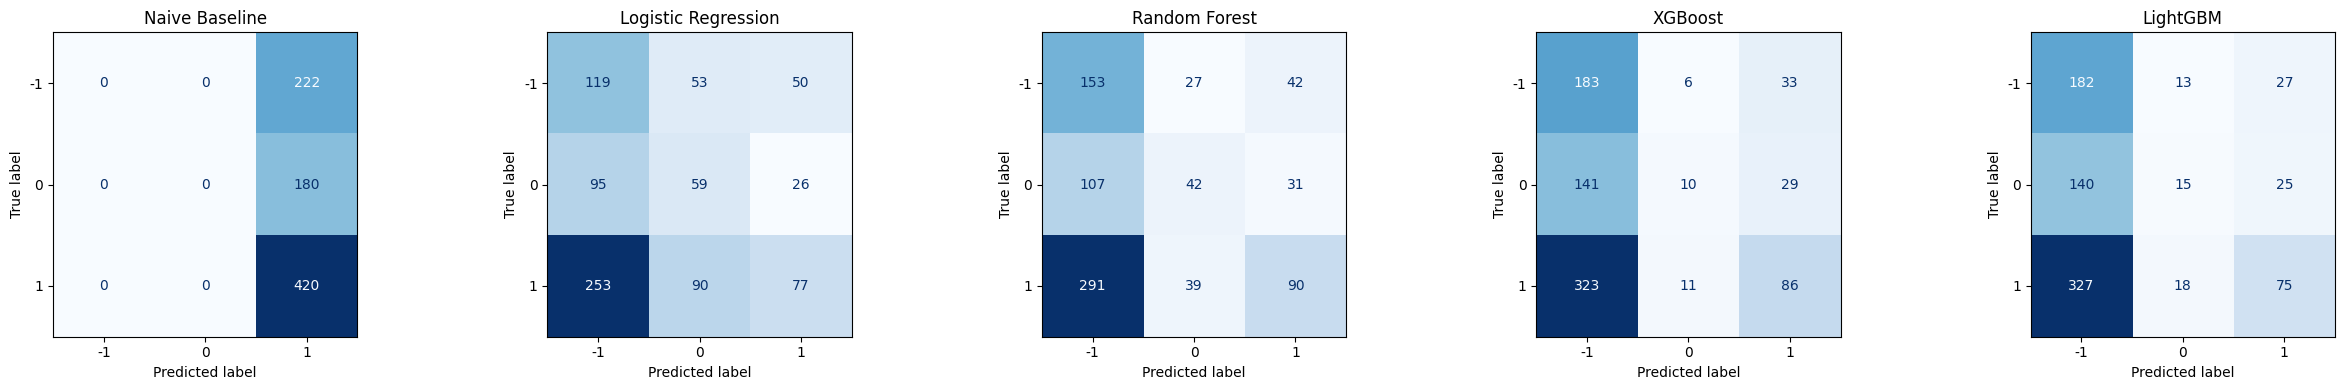

In [5]:
figure, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
if len(models) == 1:
    axes = [axes]

for axis, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        get_predictions(model, X_test),
        labels=[-1, 0, 1],
        cmap="Blues",
        ax=axis,
        colorbar=False,
    )
    axis.set_title(name)

plt.tight_layout()
plt.show()

In [6]:
best_model_name = comparison.index[0]
holdout_results = dataset.loc[X_test.index, ["date", "close", "future_return", "target"]].copy()
holdout_results["prediction"] = get_predictions(models[best_model_name], X_test)
print(f"Best holdout macro F1: {best_model_name}")
holdout_results.tail(10)

Best holdout macro F1: Random Forest


,date,close,future_return,target,prediction
4098,2026-05-19,733.729980,0.022801,1,-1
4099,2026-05-20,741.250000,0.018010,1,-1
4100,2026-05-21,742.719971,0.018527,1,-1
4101,2026-05-22,745.640015,0.017301,1,-1
4102,2026-05-26,750.590027,0.011964,1,-1
4103,2026-05-27,750.460022,0.005037,1,0
4104,2026-05-28,754.599976,0.003300,0,-1
4105,2026-05-29,756.479980,-0.025024,-1,-1
4106,2026-06-01,758.539978,-0.025470,-1,0
4107,2026-06-02,759.570007,-0.039088,-1,0


## Interpretation

The majority-class baseline is the minimum comparison standard. Holdout classification performance alone does not establish trading usefulness; the next phase evaluates delayed signals after transaction costs.